# MCDI501 - Estadística Computacional para la Toma de Decisiones

## Fase 1 - Exploración del conjunto de datos

### Proyecto

**Predicción del riesgo de enfermedad cardiovascular utilizando el estudio Framingham**

**Dataset:** Framingham Heart Study

**Integrantes**
- Pablo Rodríguez
- Luiskar Espinoza

**Fecha:** (completar)

---

## Objetivo

Realizar una exploración inicial del conjunto de datos Framingham Heart Study, identificando sus variables, tipos de datos y posibles relaciones, como base para posteriores análisis estadísticos e inferenciales.

## Contenido

1. Carga de librerías
2. Carga del conjunto de datos
3. Exploración inicial
4. Calidad de los datos
5. Estadística descriptiva
6. Visualización exploratoria
7. Interpretación preliminar

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Descripción del conjunto de datos

Se utilizará el conjunto de datos **Framingham Heart Study**, proveniente de un estudio epidemiológico orientado a identificar factores de riesgo asociados al desarrollo de enfermedad coronaria.

El dataset contiene información demográfica, clínica y de hábitos de vida de 4.238 pacientes, incluyendo variables relacionadas con presión arterial, colesterol, índice de masa corporal, diabetes, tabaquismo y antecedentes médicos.

La variable objetivo corresponde a **TenYearCHD**, que indica si un paciente desarrolló enfermedad coronaria durante un período de diez años.

In [2]:
# Ruta raíz del proyecto
PROJECT_ROOT = Path.cwd().parents[1]

# Ruta del dataset
DATASET = PROJECT_ROOT /"mcdi501_grupo6" / "datos" / "original" / "framingham.csv"

print("Proyecto:", PROJECT_ROOT)
print("Dataset:", DATASET)

Proyecto: C:\users\pablo\documents
Dataset: C:\users\pablo\documents\mcdi501_grupo6\datos\original\framingham.csv


In [3]:
df = pd.read_csv(DATASET)

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [4]:
print("Filas :", df.shape[0])
print("Columnas :", df.shape[1])

Filas : 4238
Columnas : 16


In [5]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [6]:
list(df.columns)

['male',
 'age',
 'education',
 'currentSmoker',
 'cigsPerDay',
 'BPMeds',
 'prevalentStroke',
 'prevalentHyp',
 'diabetes',
 'totChol',
 'sysBP',
 'diaBP',
 'BMI',
 'heartRate',
 'glucose',
 'TenYearCHD']

In [7]:
# Información general del dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


### Interpretación

El conjunto de datos presenta 4.238 registros y 16 variables. La mayoría de las variables son numéricas, aunque varias representan variables categóricas codificadas como valores binarios (0 y 1). Además, se observa la existencia de valores faltantes en algunas variables, aspecto que deberá abordarse en etapas posteriores del proyecto.

In [8]:
# Estadísticas descriptivas

df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [9]:
# Valores faltantes por variable

df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

### Interpretación

Los valores faltantes se concentran principalmente en variables clínicas como glucosa, colesterol, índice de masa corporal y educación. Esta información será relevante para definir posteriormente la estrategia de tratamiento de datos faltantes, procurando mantener la calidad del análisis estadístico.

In [10]:
print(f"Número de registros : {df.shape[0]}")
print(f"Número de variables : {df.shape[1]}")

Número de registros : 4238
Número de variables : 16


In [11]:
tipos = pd.DataFrame({
    "Variable": df.columns,
    "Tipo": df.dtypes.values
})

tipos

,Variable,Tipo
0,male,int64
1,age,int64
2,education,float64
3,currentSmoker,int64
4,cigsPerDay,float64
5,BPMeds,float64
6,prevalentStroke,int64
7,prevalentHyp,int64
8,diabetes,int64
9,totChol,float64


# Clasificación de las variables

El conjunto de datos contiene variables demográficas, clínicas y relacionadas con hábitos de vida.

Para facilitar el análisis estadístico, las variables se clasifican según su naturaleza.

In [12]:
clasificacion = pd.DataFrame({
    "Variable": [
        "male",
        "age",
        "education",
        "currentSmoker",
        "cigsPerDay",
        "BPMeds",
        "prevalentStroke",
        "prevalentHyp",
        "diabetes",
        "totChol",
        "sysBP",
        "diaBP",
        "BMI",
        "heartRate",
        "glucose",
        "TenYearCHD"
    ],
    "Tipo estadístico": [
        "Categórica nominal",
        "Cuantitativa continua",
        "Ordinal",
        "Categórica nominal",
        "Cuantitativa discreta",
        "Categórica nominal",
        "Categórica nominal",
        "Categórica nominal",
        "Categórica nominal",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Categórica nominal"
    ]
})

clasificacion

,Variable,Tipo estadístico
0,male,Categórica nominal
1,age,Cuantitativa continua
2,education,Ordinal
3,currentSmoker,Categórica nominal
4,cigsPerDay,Cuantitativa discreta
5,BPMeds,Categórica nominal
6,prevalentStroke,Categórica nominal
7,prevalentHyp,Categórica nominal
8,diabetes,Categórica nominal
9,totChol,Cuantitativa continua


### Interpretación

Predominan variables cuantitativas continuas relacionadas con indicadores clínicos, como presión arterial, colesterol, índice de masa corporal y glucosa. También existen variables categóricas binarias asociadas a factores de riesgo y antecedentes médicos, lo que permite aplicar distintos procedimientos estadísticos según el tipo de variable analizada.

# Estadística descriptiva

En esta sección se calculan medidas descriptivas para la variable **sysBP**, debido a que será la variable principal utilizada para contrastar la hipótesis del proyecto.

In [13]:
df["sysBP"].describe()

count    4238.000000
mean      132.352407
std        22.038097
min        83.500000
25%       117.000000
50%       128.000000
75%       144.000000
max       295.000000
Name: sysBP, dtype: float64

In [14]:
print("Media:", df["sysBP"].mean())
print("Mediana:", df["sysBP"].median())
print("Moda:", df["sysBP"].mode()[0])

Media: 132.35240679565834
Mediana: 128.0
Moda: 120.0


In [15]:
print("Desviación estándar:", df["sysBP"].std())
print("Varianza:", df["sysBP"].var())
print("Mínimo:", df["sysBP"].min())
print("Máximo:", df["sysBP"].max())
print("Rango:", df["sysBP"].max()-df["sysBP"].min())

Desviación estándar: 22.038096643544584
Varianza: 485.6777036702111
Mínimo: 83.5
Máximo: 295.0
Rango: 211.5


### Interpretación

La presión arterial sistólica presenta una amplia variabilidad entre los participantes del estudio. La comparación entre la media y la mediana permitirá evaluar preliminarmente la simetría de la distribución, mientras que la desviación estándar cuantifica la dispersión de los valores respecto del promedio.

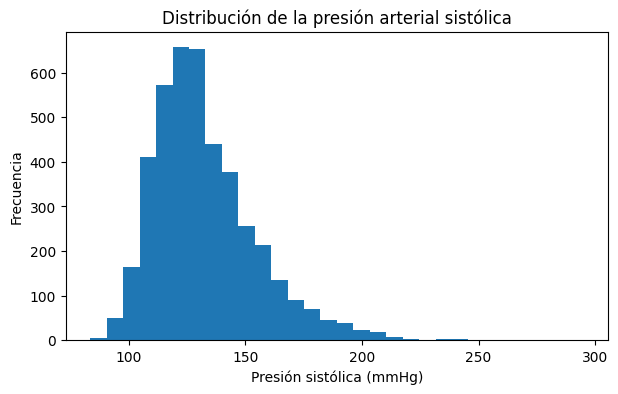

In [16]:
plt.figure(figsize=(7,4))

plt.hist(df["sysBP"], bins=30)

plt.title("Distribución de la presión arterial sistólica")

plt.xlabel("Presión sistólica (mmHg)")

plt.ylabel("Frecuencia")

plt.show()

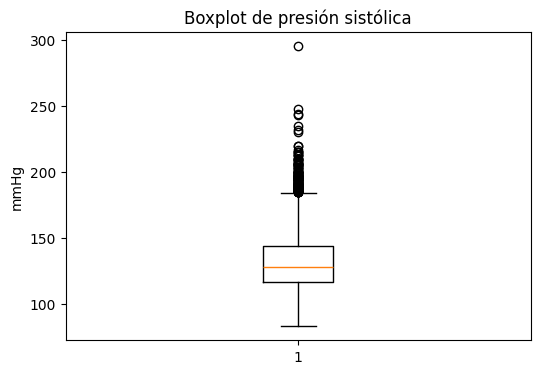

In [17]:
plt.figure(figsize=(6,4))

plt.boxplot(df["sysBP"])

plt.title("Boxplot de presión sistólica")

plt.ylabel("mmHg")

plt.show()

<Figure size 700x500 with 0 Axes>

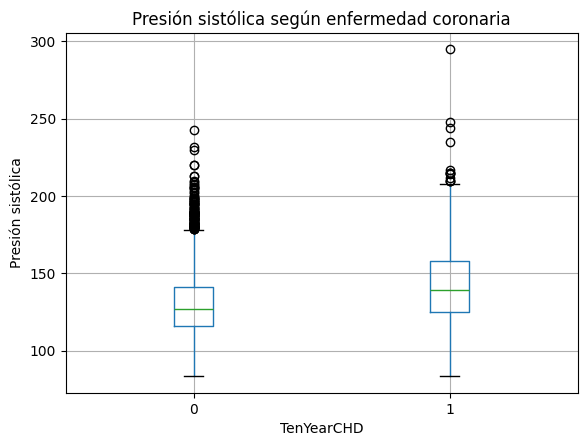

In [18]:
plt.figure(figsize=(7,5))

df.boxplot(column="sysBP", by="TenYearCHD")

plt.title("Presión sistólica según enfermedad coronaria")

plt.suptitle("")

plt.xlabel("TenYearCHD")

plt.ylabel("Presión sistólica")

plt.show()

# Hipótesis de investigación

En este proyecto se analizará la siguiente pregunta de investigación:

**¿Las personas que desarrollan enfermedad coronaria a diez años presentan una presión arterial sistólica promedio mayor que aquellas que no la desarrollan?**

Para responder esta pregunta se plantean las siguientes hipótesis estadísticas:

**Hipótesis nula (H₀):**

La presión arterial sistólica promedio es igual en ambos grupos.

\[
H_0:\mu_0=\mu_1
\]

**Hipótesis alternativa (H₁):**

La presión arterial sistólica promedio es diferente entre ambos grupos.

\[
H_1:\mu_0\neq\mu_1
\]

Se utilizará un nivel de significancia de:

\[
\alpha=0.05
\]

In [19]:
grupo_sin_chd = df[df["TenYearCHD"] == 0]["sysBP"]

grupo_con_chd = df[df["TenYearCHD"] == 1]["sysBP"]

print("Pacientes sin enfermedad:", len(grupo_sin_chd))
print("Pacientes con enfermedad:", len(grupo_con_chd))

Pacientes sin enfermedad: 3594
Pacientes con enfermedad: 644


# Estimación puntual

Como estimador puntual se utilizará la media muestral de la presión arterial sistólica para cada grupo.

In [21]:
print("Media sin enfermedad:",
      round(grupo_sin_chd.mean(),2))

print("Media con enfermedad:",
      round(grupo_con_chd.mean(),2))

Media sin enfermedad: 130.33
Media con enfermedad: 143.62


### Interpretación

La media muestral representa la mejor estimación puntual del valor promedio de la presión arterial sistólica en cada grupo de pacientes.

# Intervalo de confianza del 95 %

Se calculará un intervalo de confianza para la media poblacional de la presión arterial sistólica correspondiente al grupo de pacientes con enfermedad coronaria.

In [22]:
media = grupo_con_chd.mean()

desv = grupo_con_chd.std()

n = len(grupo_con_chd)

ic = stats.t.interval(
    confidence=0.95,
    df=n-1,
    loc=media,
    scale=desv/np.sqrt(n)
)

print("Intervalo de confianza 95%")
print(ic)

Intervalo de confianza 95%
(np.float64(141.5535200780369), np.float64(145.68405756171467))


In [23]:
print(f"Límite inferior : {ic[0]:.2f}")
print(f"Límite superior : {ic[1]:.2f}")

Límite inferior : 141.55
Límite superior : 145.68


### Interpretación

Con un nivel de confianza del 95 %, se estima que la media poblacional de la presión arterial sistólica para los pacientes que desarrollan enfermedad coronaria se encuentra dentro del intervalo calculado.

# Prueba de hipótesis

Con el propósito de evaluar si la presión arterial sistólica promedio difiere entre los pacientes que desarrollan enfermedad coronaria a diez años y aquellos que no la desarrollan, se aplicará una prueba **t de Student para dos muestras independientes**.

Se utilizará un nivel de significancia de:

\[
\alpha = 0.05
\]

El criterio de decisión será:

- Si **p < 0.05**, se rechazará la hipótesis nula.
- Si **p ≥ 0.05**, no se rechazará la hipótesis nula.

In [24]:
# Prueba t de Student para muestras independientes

t, p = stats.ttest_ind(
    grupo_sin_chd,
    grupo_con_chd,
    equal_var=False,
    nan_policy="omit"
)

print("========== PRUEBA T ==========")
print(f"Estadístico t : {t:.4f}")
print(f"Valor p       : {p:.6f}")

========== PRUEBA T ==========
Estadístico t : -12.0151
Valor p       : 0.000000


In [25]:
alpha = 0.05

if p < alpha:
    print("Decisión:")
    print("Se rechaza la hipótesis nula (H₀).")
    print("Existe evidencia estadísticamente significativa de diferencias entre ambos grupos.")
else:
    print("Decisión:")
    print("No se rechaza la hipótesis nula (H₀).")
    print("No existe evidencia suficiente para afirmar que las medias sean diferentes.")

Decisión:
Se rechaza la hipótesis nula (H₀).
Existe evidencia estadísticamente significativa de diferencias entre ambos grupos.


## Interpretación de los resultados

La prueba t de Student arrojó un estadístico **t = -12.0151** y un **valor p < 0.001**, significativamente menor que el nivel de significancia establecido (α = 0.05).

En consecuencia, se **rechaza la hipótesis nula (H₀)** y se concluye que existe evidencia estadísticamente significativa para afirmar que la presión arterial sistólica promedio difiere entre ambos grupos.

Además, los resultados muestran que los pacientes que desarrollaron enfermedad coronaria durante el período de seguimiento presentan una presión arterial sistólica promedio de **143.62 mmHg**, mientras que los pacientes que no desarrollaron la enfermedad presentan una media de **130.33 mmHg**.

Esta diferencia de aproximadamente **13.29 mmHg** sugiere que una mayor presión arterial sistólica se asocia con un mayor riesgo de desarrollar enfermedad coronaria a diez años dentro del conjunto de datos Framingham.

In [26]:
df["TenYearCHD"].value_counts()

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

In [27]:
df["TenYearCHD"].value_counts(normalize=True) * 100

TenYearCHD
0    84.804153
1    15.195847
Name: proportion, dtype: float64

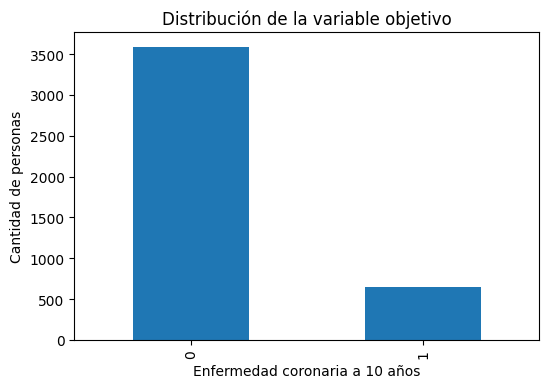

In [28]:
plt.figure(figsize=(6,4))

df["TenYearCHD"].value_counts().plot(kind="bar")

plt.title("Distribución de la variable objetivo")
plt.xlabel("Enfermedad coronaria a 10 años")
plt.ylabel("Cantidad de personas")

plt.show()

### Interpretación

La variable objetivo presenta una distribución desbalanceada, observándose una mayor cantidad de personas que no desarrollaron enfermedad coronaria durante el período de estudio. Este comportamiento deberá considerarse en análisis posteriores, especialmente al aplicar técnicas de inferencia estadística o modelos predictivos.

# Conclusiones

A partir del análisis estadístico realizado sobre el conjunto de datos Framingham Heart Study, se identificó una diferencia estadísticamente significativa en la presión arterial sistólica entre los pacientes que desarrollaron enfermedad coronaria y aquellos que no la desarrollaron.

Los resultados obtenidos mediante la prueba t de Student respaldan la hipótesis de investigación planteada, indicando que los individuos con enfermedad coronaria presentan, en promedio, una presión arterial sistólica superior.

Estos hallazgos son coherentes con la evidencia clínica disponible, que reconoce la hipertensión arterial como uno de los principales factores de riesgo para el desarrollo de enfermedades cardiovasculares. En consecuencia, la presión arterial sistólica constituye una variable de gran relevancia para futuros análisis estadísticos y modelos predictivos orientados a estimar el riesgo cardiovascular.